In [1]:
from models import *

from dataloader import RelDataset
from utils import visualize_graph
from tqdm import tqdm
import random

import matplotlib.pyplot as plt

dataset = RelDataset('COCO', max_samples=100, split='train', masks=True, negative=False)

Loading data from /home/maelic/Documents/Postdoc/OpenVocSGG/data/RLIPv2_train2017_threshold20_Tagger2_Noi24_20e_Xattnmask_SceneGraph_model_large_caption_nucleus10_thre05.json...


In [2]:
# load models
llava_model = GPT4Model(device='cuda:0')

# llama_model = LlamaModel(device='cuda:0')

# gpt4_model = GPT4Model(device='cuda:1')

models = {'llava': llava_model} #, 'gpt4': gpt4_model, 'llama': llama_model

In [3]:
CoT_spatial = """
            Analyze the provided image and the two annotated masks. Focus only on the direct relative position between the two entities, with the blue mask being Entity 1 (subject) and the red mask Entity 2 (object). Follow these steps:\n
            \n
            1. **Entity Position**: Briefly describe the location of each entity in the image (e.g., top-left, center-right).\n
            \n
            2. **Depth Analysis**: Assess the depth of each entity based on their position in the image. Consider which entity appears closer or farther away from the camera, and whether one entity is occluded by the other.\n
            3. **Predicate Selection**: Determine the most accurate direct relative position between the two entities. Use only one of the following predicates:\n
            - **Below**: Entity 1 is completely or partially below Entity 2 along the vertical axis.\n
            - **Above**: Entity 1 is completely or partially above Entity 2 along the vertical axis.\n
            - **Right of**: Entity 1 is horizontally positioned to the right of Entity 2, with no significant vertical overlap.\n
            - **Left of**: Entity 1 is horizontally positioned to the left of Entity 2, with no significant vertical overlap.\n
            - **Behind**: Entity 1 appears farther back in depth relative to Entity 2 (based on image perspective or occlusion).\n
            - **In front of**: Entity 1 appears closer in depth relative to Entity 2 (based on image perspective or occlusion).\n
            \n
            4. **Reasoning**: Provide a concise explanation for your choice, considering both spatial arrangement and perspective.\n
            \n
            5. **Consistency Check**: Double-check that the selected predicate aligns with the spatial arrangement described in Step 1 and 2. Remember that Entity 1 (blue mask) is the subject of the relation and Entity 2 (red mask) is the object of the relation. The chosen predicate need to take into account the direction of the relation (from subject to object). All relations are in the perspective of the camera. \n
            \n
            Finally, summarize the spatial relationship between the two entities in the format: <rel></rel>. For example: person <rel>to the left of</rel> dog.""" # . In this image, the entities are """+sub+" and "+obj+"


('1_person', '2_person')


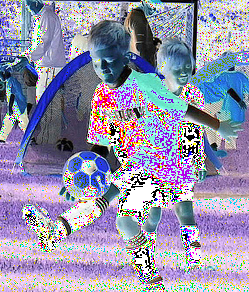

In [12]:
img_full, img_cropped, img, pair, boxes = dataset.get_random_pair(intersect=True)
print(pair)
display(img_cropped)

In [5]:
data, img_data = dataset.get_data()

graphs = {'llava': [], 'gpt4': [], 'llama': []}
imgs = []

rel_id = 0

num_img = 1

data_gen = zip(data, img_data)
# take a random sample from data_gen
data_gen = random.sample(list(data_gen), num_img)

for i, (sample, img_d) in enumerate(data_gen):
    img, pairs = dataset.get_sample(sample, img_d['img_path'], True)
    if i == num_img:
        break
    imgs.append(img)
    pairs = dataset.data_sampling(pairs, 25, max_samples=25)

    for model_name, graph in graphs.items():
        new_data = sample.copy()
        new_data['relationships'] = []
        graph.append(new_data)

    for pair in tqdm(pairs):
        img_neg, img_cropped, img3, labels, bboxes = dataset.get_pair_data(img, pair)
        
        for model_name, model in models.items():
            predicate, _ = model.generate(labels, img_cropped, prompt_template=CoT_spatial)
            if predicate != None:
                rel_id += 1
                graphs[model_name][i]['relationships'].append({
                    'relationship_id': rel_id,
                    'subject_id': pair[0]['id'],
                    'predicate': predicate,
                    'object_id': pair[1]['id'],
                    'confidence': 1.0
                })

        # pbar.set_description(f"Rels gen: {rel_id} / {len(pairs)}")

100%|██████████| 1/1 [00:05<00:00,  5.84s/it]


Image 0
Model: llava
Counter({'above': 1})
1


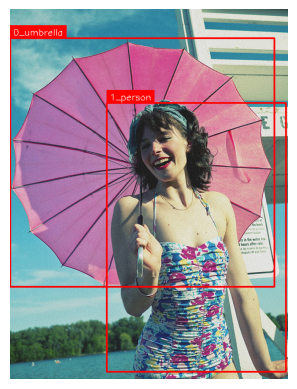

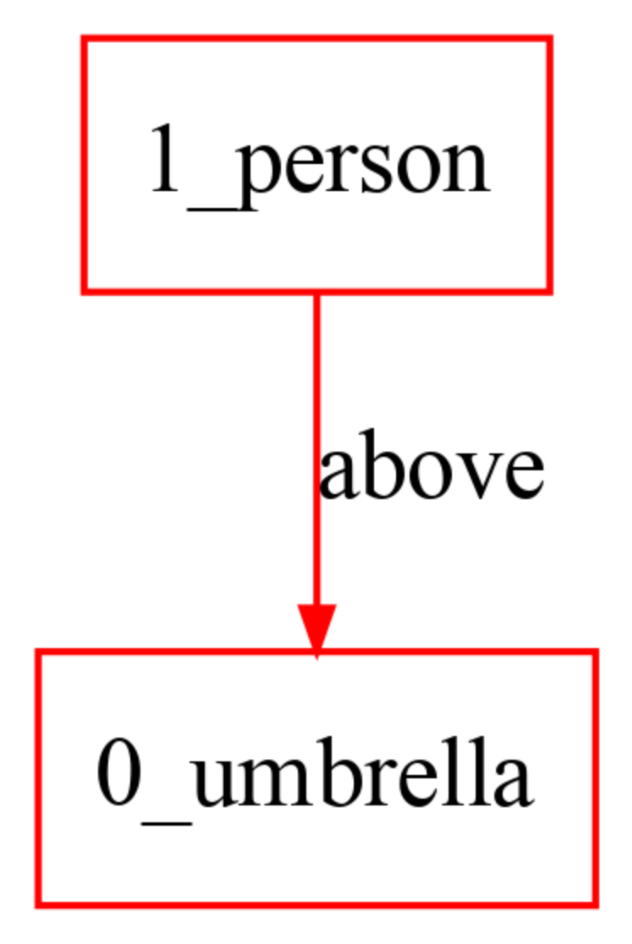

Model: gpt4
Counter()
0


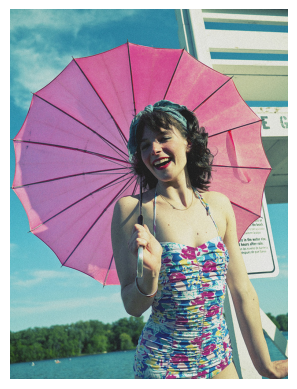

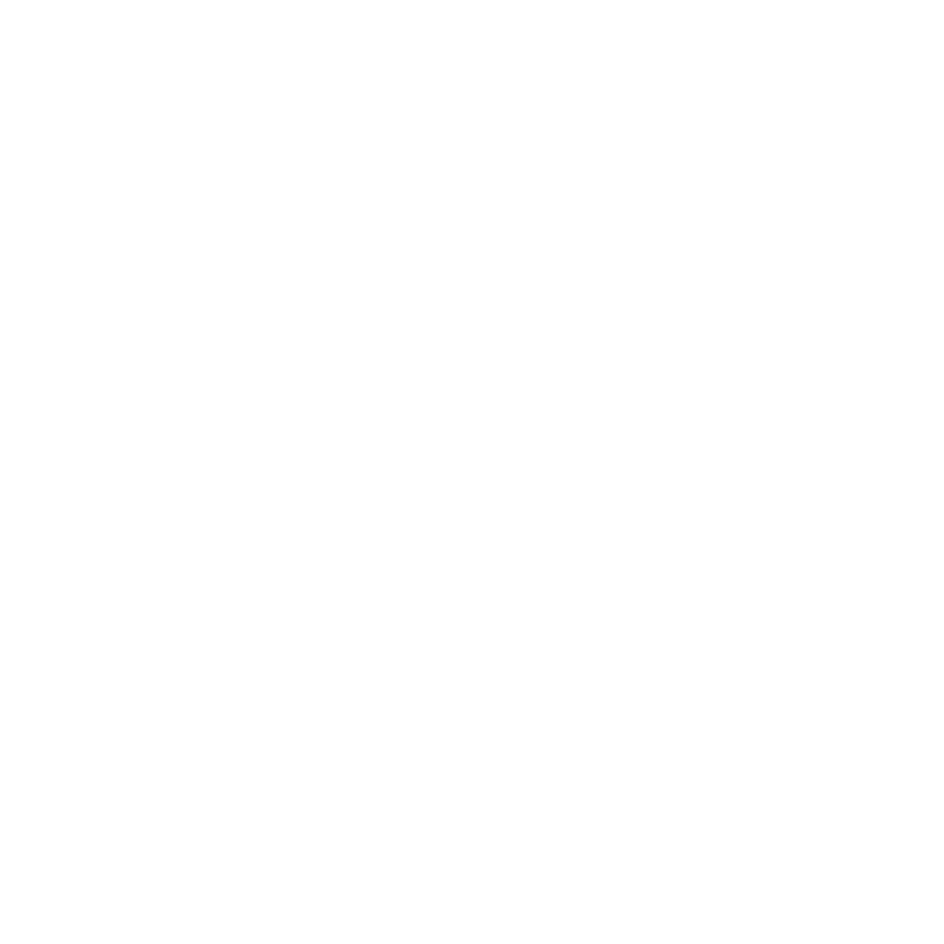

Model: llama
Counter()
0


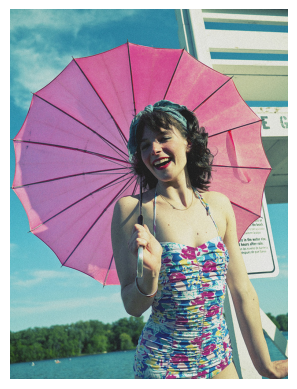

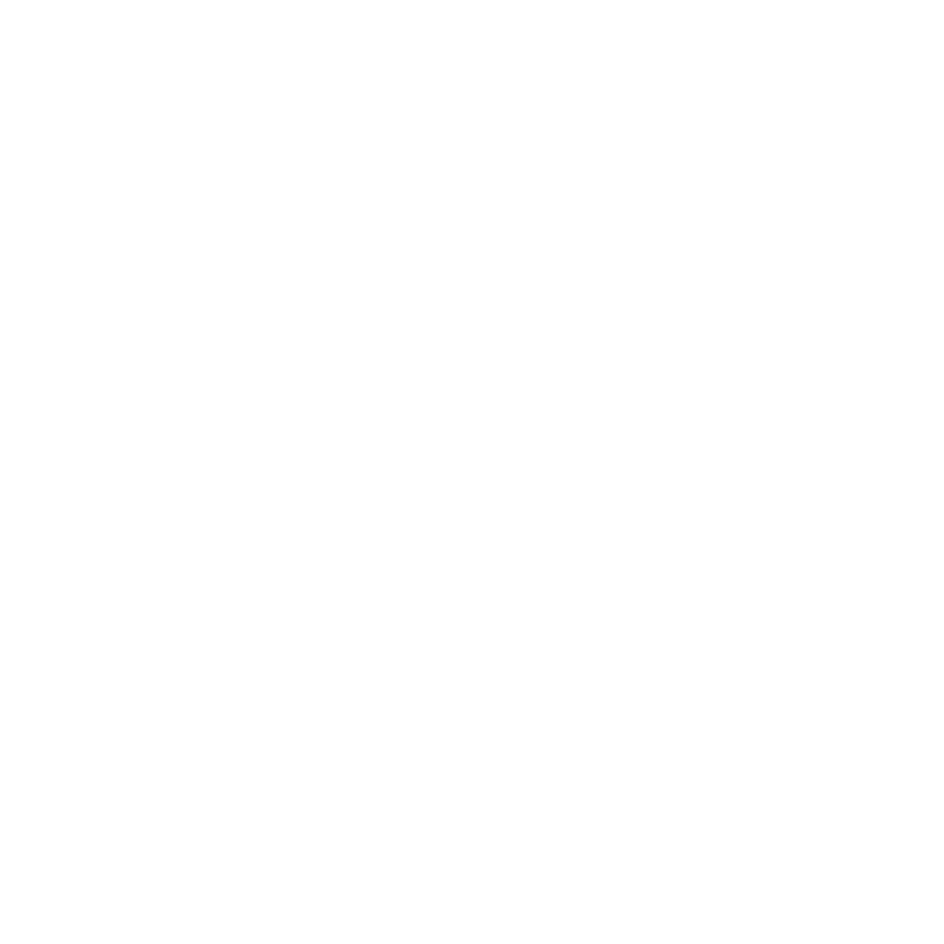

In [6]:
import random
from collections import Counter
i = random.randint(0, num_img-1)
print(f"Image {i}")

for model_name, graph in graphs.items():
    # random indice in size of the graph
    print(f"Model: {model_name}")
    current_rels = []
    to_remove = []
    for r in graph[i]['relationships']:
        if (r['subject_id'], r['object_id']) not in current_rels:
            current_rels.append((r['subject_id'], r['object_id']))
        else:
            to_remove.append(r)
    count_pred = Counter([r['predicate'] for r in graph[i]['relationships']])
    print(count_pred)
    print(len(count_pred))
    # print(len(count_pred) / len(graph[i]['relationships']))

    graph[i]['relationships'] = [x for x in graph[i]['relationships'] if x not in to_remove]

    img = imgs[i]
    img_graph, img_boxes = visualize_graph(graph[i]['relationships'], graph[i]['objects'], img)

    # visualize the box image
    plt.imshow(img_boxes)
    plt.axis('off')
    plt.show()

    # visualize the graph
    fig = plt.figure(figsize=(12, 12))
    plt.imshow(img_graph)
    plt.axis('off')
    plt.show()

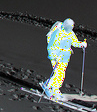

In [7]:
data, img_data = dataset.get_data()

img_orig, img_cropped, img, pair, boxes = dataset.get_random_pair(intersect=False)
display(img_cropped)

In [8]:
output, out_raw = models['llava'].generate(pair, img_cropped)

print(output)
print(out_raw)
display(img_cropped)

KeyboardInterrupt: 

In [ ]:
output, out_raw = model.generate(pair, img_cropped)

print(output)
print(out_raw)
display(img_cropped)

NameError: name 'model' is not defined

In [ ]:
import tensorflow as tf
from PIL import Image
import requests
from transformers import AutoProcessor, AutoModel

model = AutoModel.from_pretrained("openai/clip-vit-base-patch32")
processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)

inputs = processor(
    text=["a photo of a cat", "a photo of a dog"], images=image, return_tensors="pt", padding=True
)

outputs = model(**inputs)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [ ]:
print(outputs.keys())

odict_keys(['logits_per_image', 'logits_per_text', 'text_embeds', 'image_embeds', 'text_model_output', 'vision_model_output'])


In [ ]:
from vllm import LLM, SamplingParams
from vllm.assets.image import ImageAsset
from dataloader import DataLoader

data = DataLoader('COCO')

# Initialize the LLM
model_name = "neuralmagic/Llama-3.2-11B-Vision-Instruct-FP8-dynamic"
llm = LLM(model=model_name, max_num_seqs=1, enforce_eager=True, max_model_len=4096,tensor_parallel_size=2)


KeyboardInterrupt



Analyze the provided image and the two annotated bounding boxes. Focus only on describing their spatial relationship:
 1. **Position**: Describe the position of each entity in the image briefly (e.g., top-left, bottom-center).
 2. **Relative Location**: How are the entities positioned relative to each other (e.g., above, below, next to)?
 3. **Proximity**: Are they near, touching, or far apart?
 4. **Direction**: Specify the direction (e.g., to the left of, diagonally above).
 Summarize the spatial relationship in the format: <rel>[spatial relationship]</rel>. For example: Entity 1 is <rel>above</rel> Entity 2.


Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:05<00:00,  5.06s/it, est. speed input: 29.86 toks/s, output: 29.66 toks/s]

 Entity 2 is <rel>next to</rel> Entity 1.

1. The blue rectangle is in the top-left corner of the image. It is above the red rectangle.
2. The red rectangle is on the right side of the image, and it is next to the blue rectangle. The red rectangle is also below the blue rectangle. The red rectangle is on the right side of the image, and it is next to the blue rectangle. The red rectangle is also below the blue rectangle. The red rectangle is on the right side of the image, and it is next to the blue rectangle. The red rectangle is also below the blue rectangle. The red rectangle is on the right side of the image, and it is next to
next to


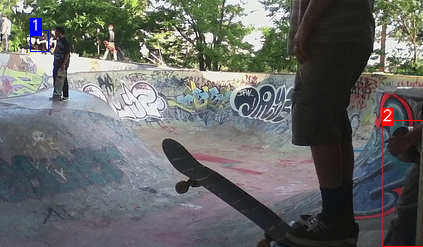

In [ ]:
# Load the image
img_orig, img_cropped, img, pair, boxes = data.get_random_pair(intersect=False)

# Create the prompt
prompt = "Analyze the provided image and the two annotated bounding boxes. Focus only on describing their spatial relationship:\n 1. **Position**: Describe the position of each entity in the image briefly (e.g., top-left, bottom-center).\n 2. **Relative Location**: How are the entities positioned relative to each other (e.g., above, below, next to)?\n 3. **Proximity**: Are they near, touching, or far apart?\n 4. **Direction**: Specify the direction (e.g., to the left of, diagonally above).\n Summarize the spatial relationship in the format: <rel>[spatial relationship]</rel>. For example: Entity 1 is <rel>above</rel> Entity 2."
print(prompt)
prompt = f"<|image|><|begin_of_text|>{prompt}"

# Set up sampling parameters
sampling_params = SamplingParams(temperature=0.1, max_tokens=150)

# Generate the response
inputs = {
    "prompt": prompt,
    "multi_modal_data": {
        "image": img_cropped
    },
}
outputs = llm.generate(inputs, sampling_params=sampling_params)

# Print the generated text
response = outputs[0].outputs[0].text
# get the relation between the <pred></pred> tags
print(response)
relation = response.split("<rel>")[1].split("</rel>")[0]
print(relation)
display(img_cropped)